# 03 Model Evaluation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
import torch
from ultralytics import YOLO
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import label_binarize

In [3]:
#paths 
BASE_DIR      = Path("../")
VAL_DIR       = BASE_DIR / "data/statefarm_subject_split/val"

BASELINE_WEIGHTS    = Path("runs/yolov8n_statefarm/weights/best.pt")
REGULARIZED_WEIGHTS = Path("runs/yolov8n_statefarm_regularized/weights/best.pt")
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

#class labels
CLASS_NAMES = [
    "c0: Safe Driving",
    "c1: Texting (Right)",
    "c2: Phone (Right)",
    "c3: Texting (Left)",
    "c4: Phone (Left)",
    "c5: Radio",
    "c6: Drinking",
    "c7: Reaching Behind",
    "c8: Hair/Makeup",
    "c9: Talking to Passenger"
]

SHORT_NAMES = ["c0","c1","c2","c3","c4","c5","c6","c7","c8","c9"]
NUM_CLASSES = 10


In [4]:
# load both trained models
model_baseline    = YOLO(str(BASELINE_WEIGHTS))
model_regularized = YOLO(str(REGULARIZED_WEIGHTS))

In [5]:
def collect_predictions(model, val_dir, num_classes=10):
    y_true, y_pred, y_probs = [], [], []
    val_path = Path(val_dir)

    class_folders = sorted([d for d in val_path.iterdir() if d.is_dir()])
    class_to_idx  = {folder.name: i for i, folder in enumerate(class_folders)}

    print(f"Found {len(class_folders)} class folders")
    total = 0

    for class_folder in class_folders:
        true_idx = class_to_idx[class_folder.name]
        image_files = [f for f in class_folder.iterdir()
                       if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]

        for img_path in image_files:
            result = model.predict(str(img_path), imgsz=224, verbose=False)[0]
            probs  = result.probs.data.cpu().numpy()   # shape: (10,)
            pred_idx = int(np.argmax(probs))

            y_true.append(true_idx)
            y_pred.append(pred_idx)
            y_probs.append(probs)
            total += 1

        print(f"  [{class_folder.name}] done — {len(image_files)} images")

    return np.array(y_true), np.array(y_pred), np.array(y_probs)


print("running baseline model on validation set")
y_true_b, y_pred_b, y_probs_b = collect_predictions(model_baseline, VAL_DIR)

print("\nrunning regularized model on validation set")
y_true_r, y_pred_r, y_probs_r = collect_predictions(model_regularized, VAL_DIR)


running baseline model on validation set
Found 10 class folders
  [c0] done — 457 images
  [c1] done — 355 images
  [c2] done — 376 images
  [c3] done — 406 images
  [c4] done — 389 images
  [c5] done — 401 images
  [c6] done — 394 images
  [c7] done — 378 images
  [c8] done — 324 images
  [c9] done — 366 images

running regularized model on validation set
Found 10 class folders
  [c0] done — 457 images
  [c1] done — 355 images
  [c2] done — 376 images
  [c3] done — 406 images
  [c4] done — 389 images
  [c5] done — 401 images
  [c6] done — 394 images
  [c7] done — 378 images
  [c8] done — 324 images
  [c9] done — 366 images


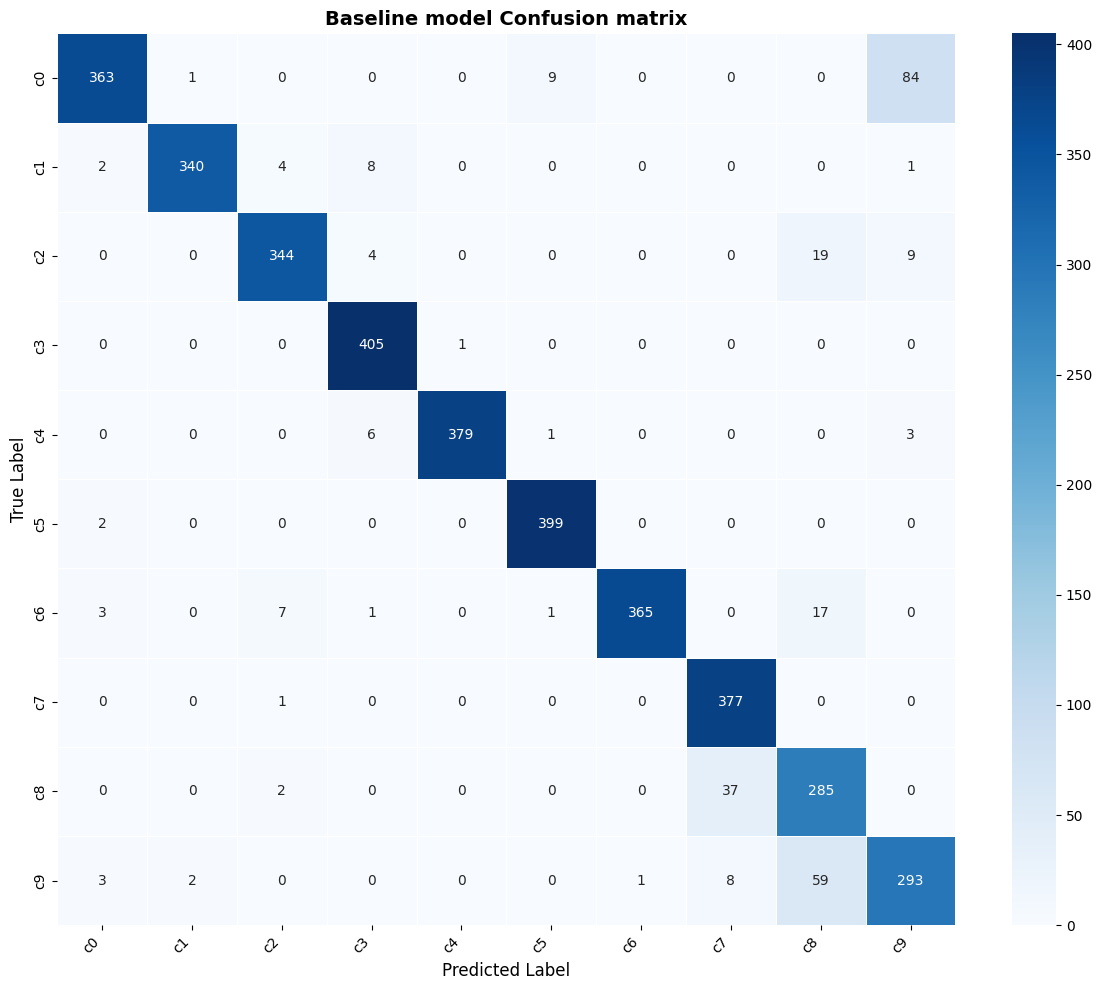

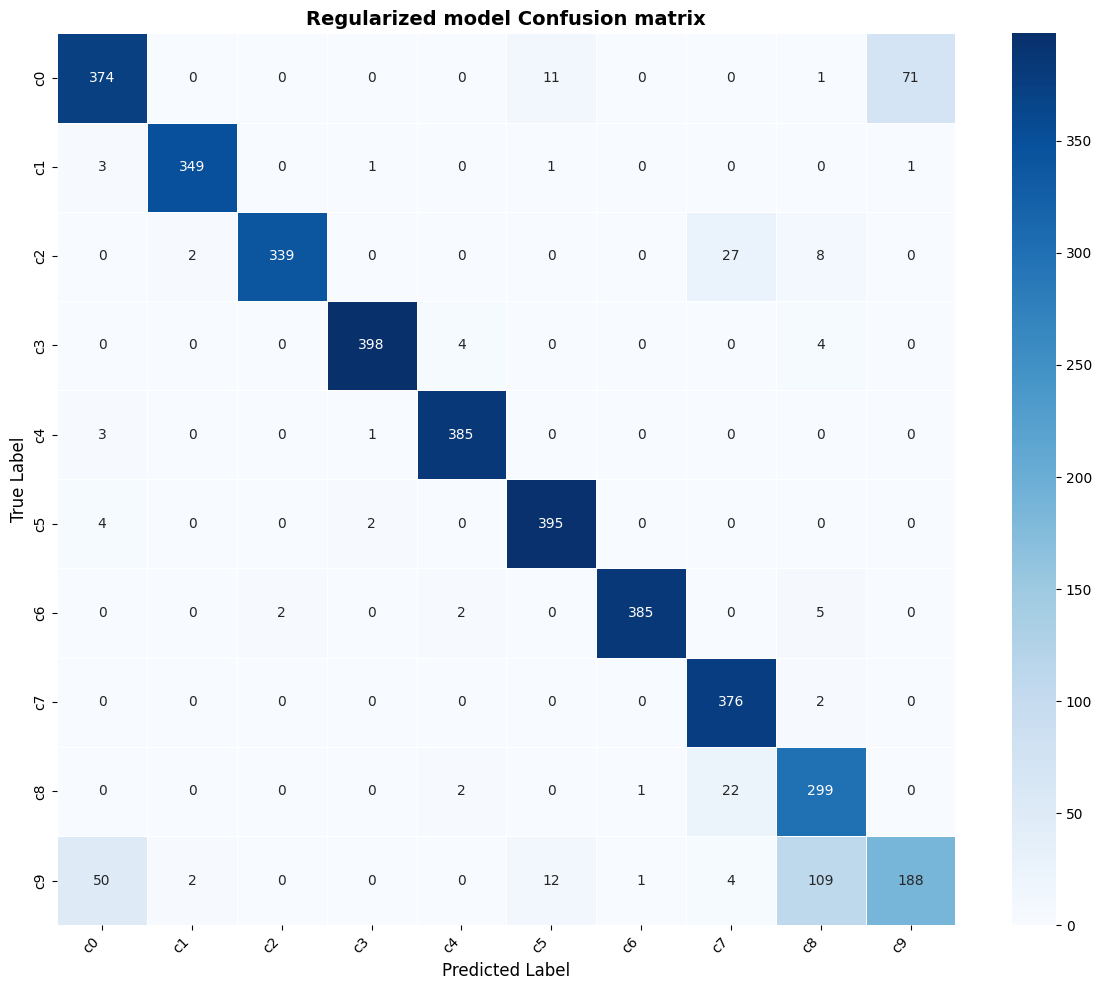

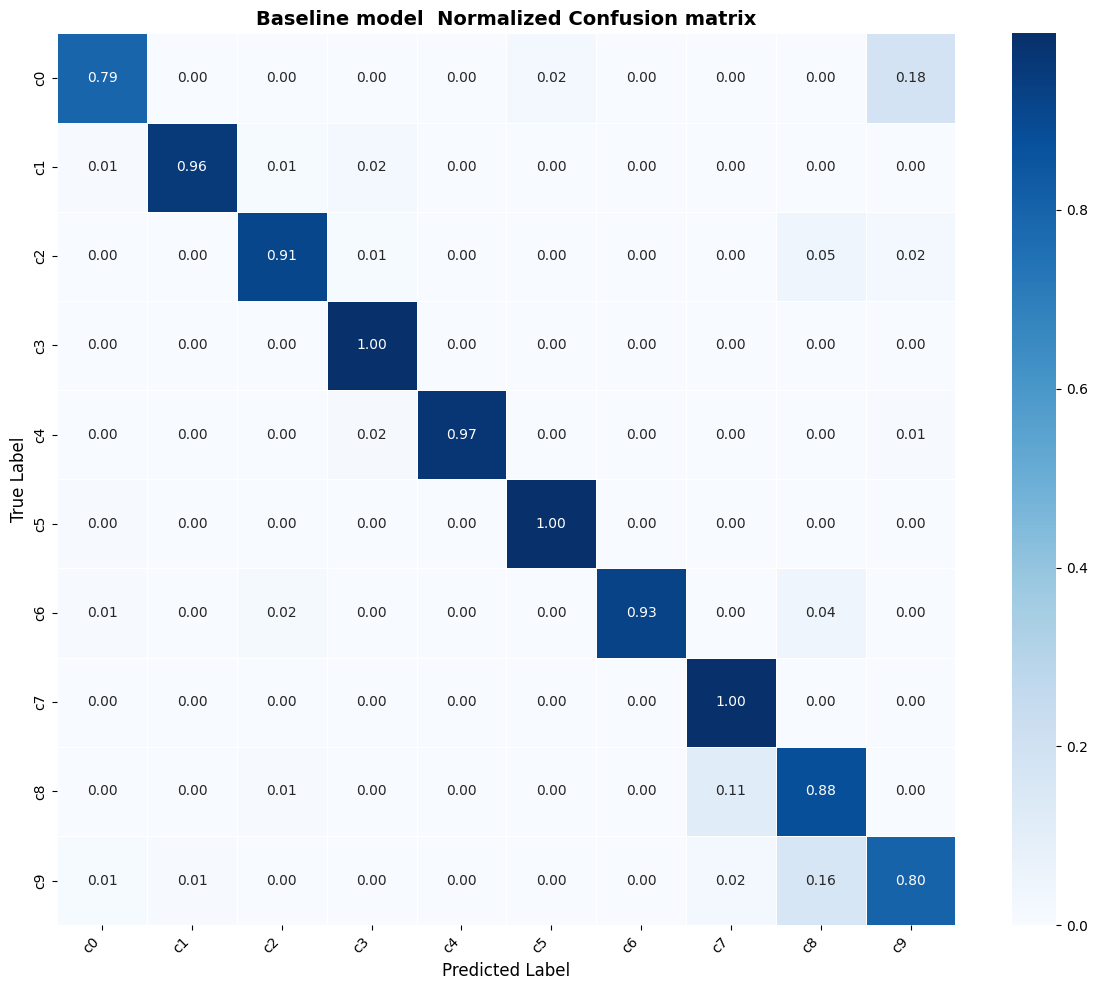

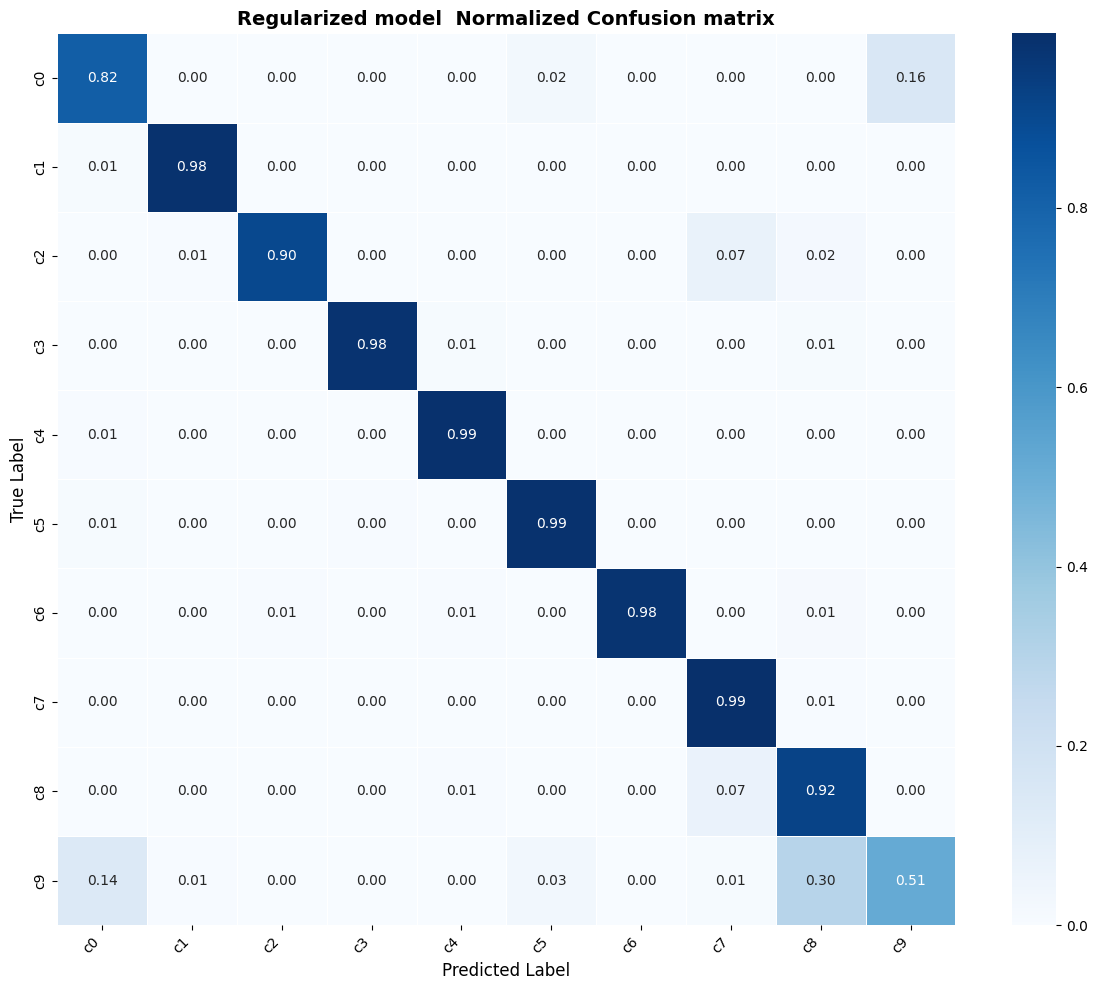

In [6]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, save_path=None, normalize=False):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
    else:
        fmt = "d"

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, ax=ax
    )
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

#confusion matrices
plot_confusion_matrix(y_true_b, y_pred_b, SHORT_NAMES,
    title="Baseline model Confusion matrix",
    save_path=REPORTS_DIR / "cm_baseline_raw.png")

plot_confusion_matrix(y_true_r, y_pred_r, SHORT_NAMES,
    title="Regularized model Confusion matrix",
    save_path=REPORTS_DIR / "cm_regularized_raw.png")

#normalized confusion matrices
plot_confusion_matrix(y_true_b, y_pred_b, SHORT_NAMES,
    title="Baseline model  Normalized Confusion matrix",
    save_path=REPORTS_DIR / "cm_baseline_norm.png", normalize=True)

plot_confusion_matrix(y_true_r, y_pred_r, SHORT_NAMES,
    title="Regularized model  Normalized Confusion matrix",
    save_path=REPORTS_DIR / "cm_regularized_norm.png", normalize=True)

In [8]:

def print_classification_report(y_true, y_pred, model_name):
    print(f" Classification Report — {model_name}")
    report = classification_report(
        y_true, y_pred,
        target_names=SHORT_NAMES,
        digits=4
    )
    print(report)
#overall metrics
    acc = np.mean(y_true == y_pred)
    macro_f1  = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    print(f"Top 1 Accuracy   : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Macro F1 Score   : {macro_f1:.4f}")
    print(f"Weighted F1 Score: {weighted_f1:.4f}")
    return report


print_classification_report(y_true_b, y_pred_b, "baseline")
print_classification_report(y_true_r, y_pred_r, "Regularized")

 Classification Report — baseline
              precision    recall  f1-score   support

          c0     0.9732    0.7943    0.8747       457
          c1     0.9913    0.9577    0.9742       355
          c2     0.9609    0.9149    0.9373       376
          c3     0.9552    0.9975    0.9759       406
          c4     0.9974    0.9743    0.9857       389
          c5     0.9732    0.9950    0.9840       401
          c6     0.9973    0.9264    0.9605       394
          c7     0.8934    0.9974    0.9425       378
          c8     0.7500    0.8796    0.8097       324
          c9     0.7513    0.8005    0.7751       366

    accuracy                         0.9230      3846
   macro avg     0.9243    0.9238    0.9220      3846
weighted avg     0.9289    0.9230    0.9238      3846

Top 1 Accuracy   : 0.9230 (92.30%)
Macro F1 Score   : 0.9220
Weighted F1 Score: 0.9238
 Classification Report — Regularized
              precision    recall  f1-score   support

          c0     0.8618    0

'              precision    recall  f1-score   support\n\n          c0     0.8618    0.8184    0.8395       457\n          c1     0.9887    0.9831    0.9859       355\n          c2     0.9941    0.9016    0.9456       376\n          c3     0.9900    0.9803    0.9851       406\n          c4     0.9796    0.9897    0.9847       389\n          c5     0.9427    0.9850    0.9634       401\n          c6     0.9948    0.9772    0.9859       394\n          c7     0.8765    0.9947    0.9318       378\n          c8     0.6986    0.9228    0.7952       324\n          c9     0.7231    0.5137    0.6006       366\n\n    accuracy                         0.9069      3846\n   macro avg     0.9050    0.9066    0.9018      3846\nweighted avg     0.9085    0.9069    0.9040      3846\n'

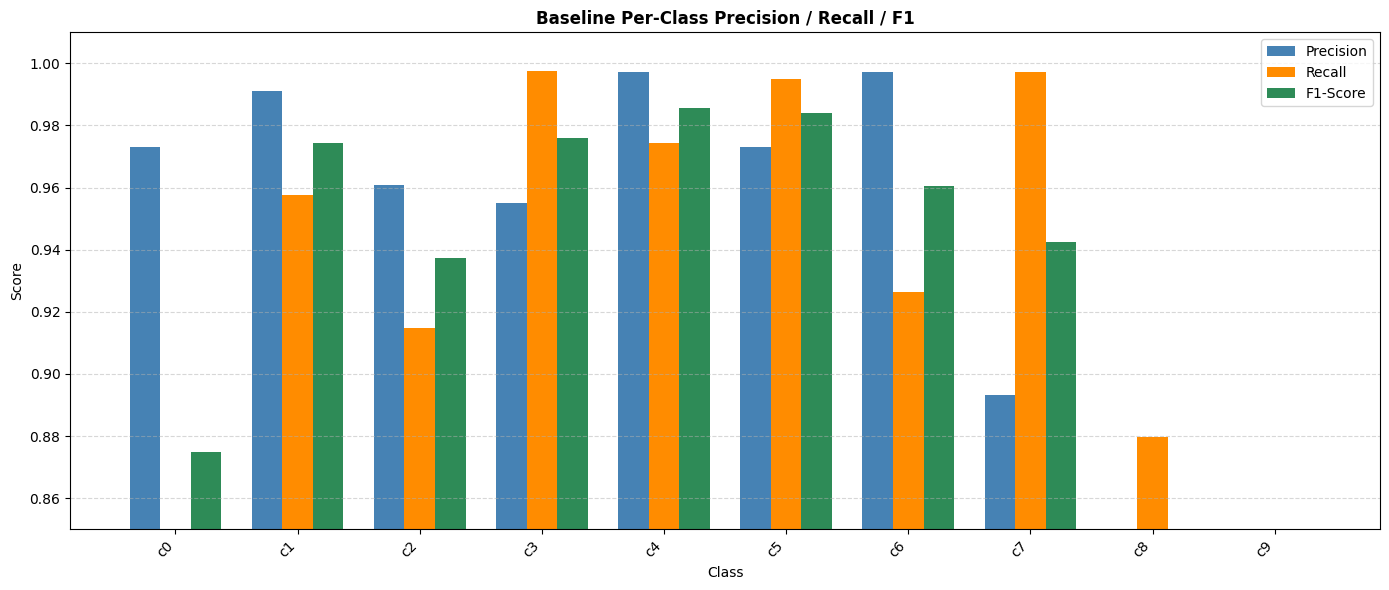

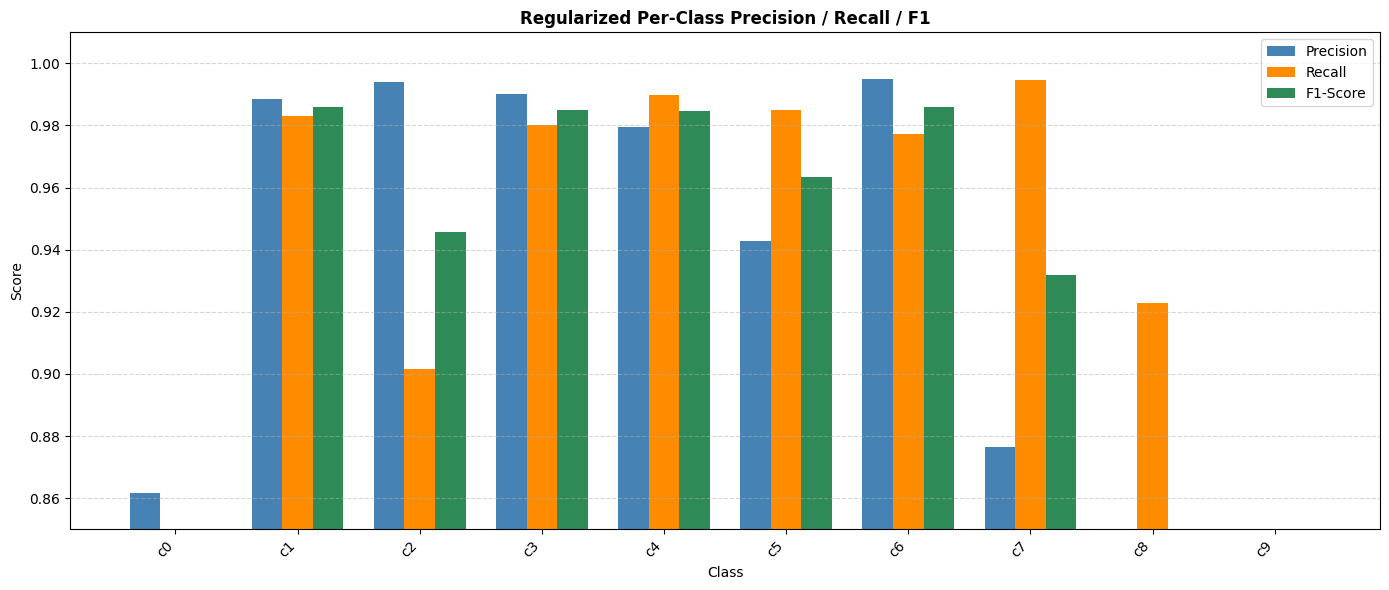

In [9]:
#per class metrics bar chart
def plot_per_class_metrics(y_true, y_pred, model_name, save_path=None):
    precision = precision_score(y_true, y_pred, average=None)
    recall    = recall_score(y_true, y_pred, average=None)
    f1        = f1_score(y_true, y_pred, average=None)

    x = np.arange(NUM_CLASSES)
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x - width, precision, width, label="Precision", color="steelblue")
    ax.bar(x,         recall,    width, label="Recall",    color="darkorange")
    ax.bar(x + width, f1,        width, label="F1-Score",  color="seagreen")

    ax.set_xlabel("Class")
    ax.set_ylabel("Score")
    ax.set_title(f"{model_name} Per-Class Precision / Recall / F1", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(SHORT_NAMES, rotation=45, ha="right")
    ax.set_ylim(0.85, 1.01)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_per_class_metrics(y_true_b, y_pred_b, "Baseline",
    save_path=REPORTS_DIR / "metrics_baseline.png")
plot_per_class_metrics(y_true_r, y_pred_r, "Regularized",
    save_path=REPORTS_DIR / "metrics_regularized.png")

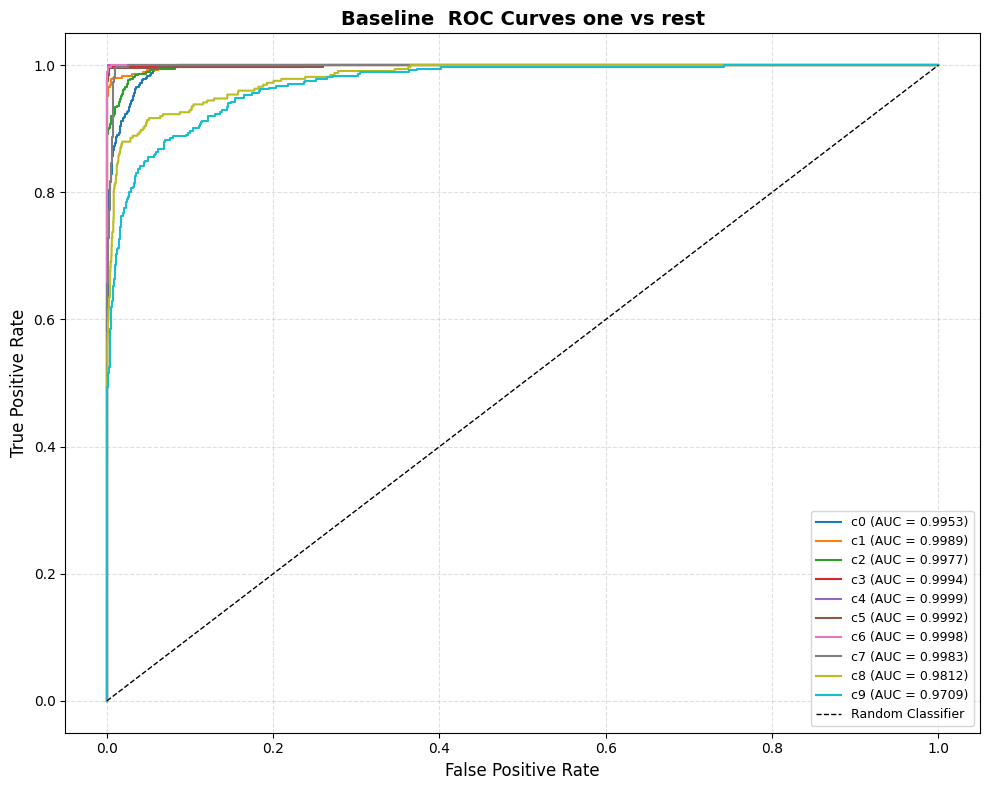


Mean AUC (Baseline): 0.9941
  c0: 0.9953
  c1: 0.9989
  c2: 0.9977
  c3: 0.9994
  c4: 0.9999
  c5: 0.9992
  c6: 0.9998
  c7: 0.9983
  c8: 0.9812
  c9: 0.9709


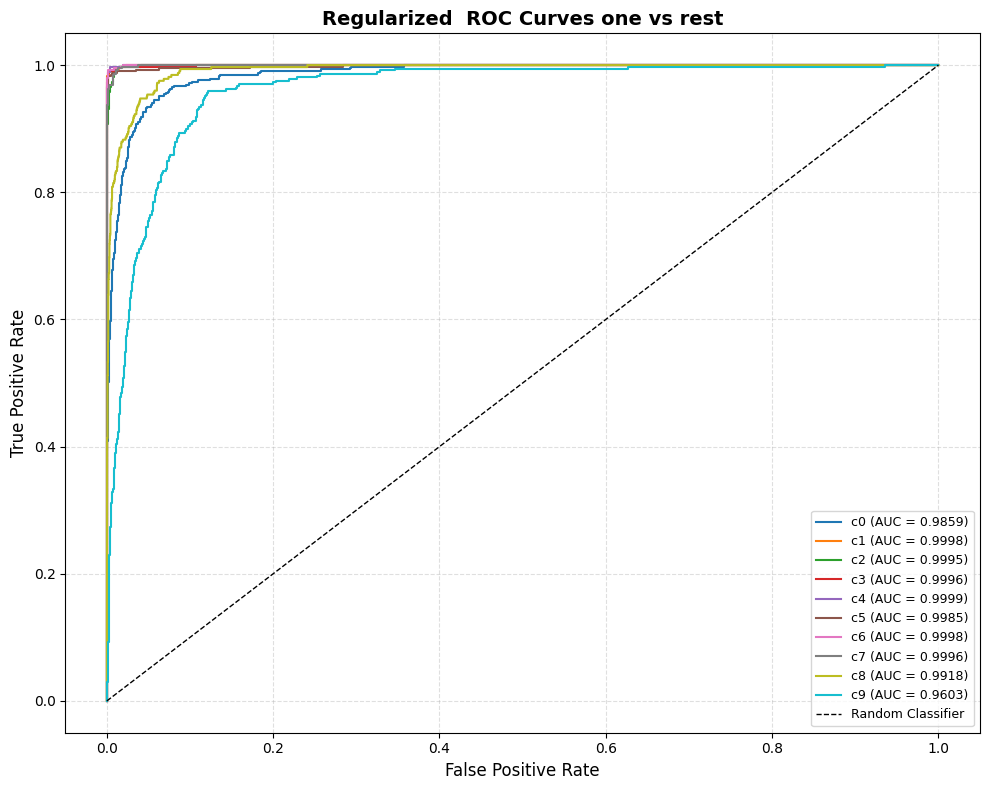


Mean AUC (Regularized): 0.9935
  c0: 0.9859
  c1: 0.9998
  c2: 0.9995
  c3: 0.9996
  c4: 0.9999
  c5: 0.9985
  c6: 0.9998
  c7: 0.9996
  c8: 0.9918
  c9: 0.9603


In [10]:
def plot_roc_curves(y_true, y_probs, model_name, save_path=None):
    #binarize labels for one-vs-rest
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

    auc_scores = []
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        ax.plot(fpr, tpr, color=colors[i], lw=1.5,
                label=f"{SHORT_NAMES[i]} (AUC = {roc_auc:.4f})")

    #diagonal reference line
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")

    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title(f"{model_name}  ROC Curves one vs rest", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    mean_auc = np.mean(auc_scores)
    print(f"\nMean AUC ({model_name}): {mean_auc:.4f}")
    for i, s in enumerate(auc_scores):
        print(f"  {SHORT_NAMES[i]}: {s:.4f}")
    return auc_scores


auc_baseline    = plot_roc_curves(y_true_b, y_probs_b, "Baseline",
    save_path=REPORTS_DIR / "roc_baseline.png")
auc_regularized = plot_roc_curves(y_true_r, y_probs_r, "Regularized",
    save_path=REPORTS_DIR / "roc_regularized.png")

In [11]:
def summarise_model(y_true, y_pred, y_probs, auc_scores, label):
    acc          = np.mean(y_true == y_pred)
    macro_p      = precision_score(y_true, y_pred, average="macro")
    macro_r      = recall_score(y_true, y_pred, average="macro")
    macro_f1     = f1_score(y_true, y_pred, average="macro")
    mean_auc     = np.mean(auc_scores)
    return {
        "Model":          label,
        "Top 1 accuracy": f"{acc*100:.2f}%",
        "Macro precision":f"{macro_p:.4f}",
        "Macro recall":   f"{macro_r:.4f}",
        "Macro F1":       f"{macro_f1:.4f}",
        "Mean AUC":       f"{mean_auc:.4f}",
    }

summary_b = summarise_model(y_true_b, y_pred_b, y_probs_b, auc_baseline,    "Baseline")
summary_r = summarise_model(y_true_r, y_pred_r, y_probs_r, auc_regularized, "Regularized")

comparison_df = pd.DataFrame([summary_b, summary_r]).set_index("Model")
print(comparison_df.to_string())

            Top 1 accuracy Macro precision Macro recall Macro F1 Mean AUC
Model                                                                    
Baseline            92.30%          0.9243       0.9238   0.9220   0.9941
Regularized         90.69%          0.9050       0.9066   0.9018   0.9935


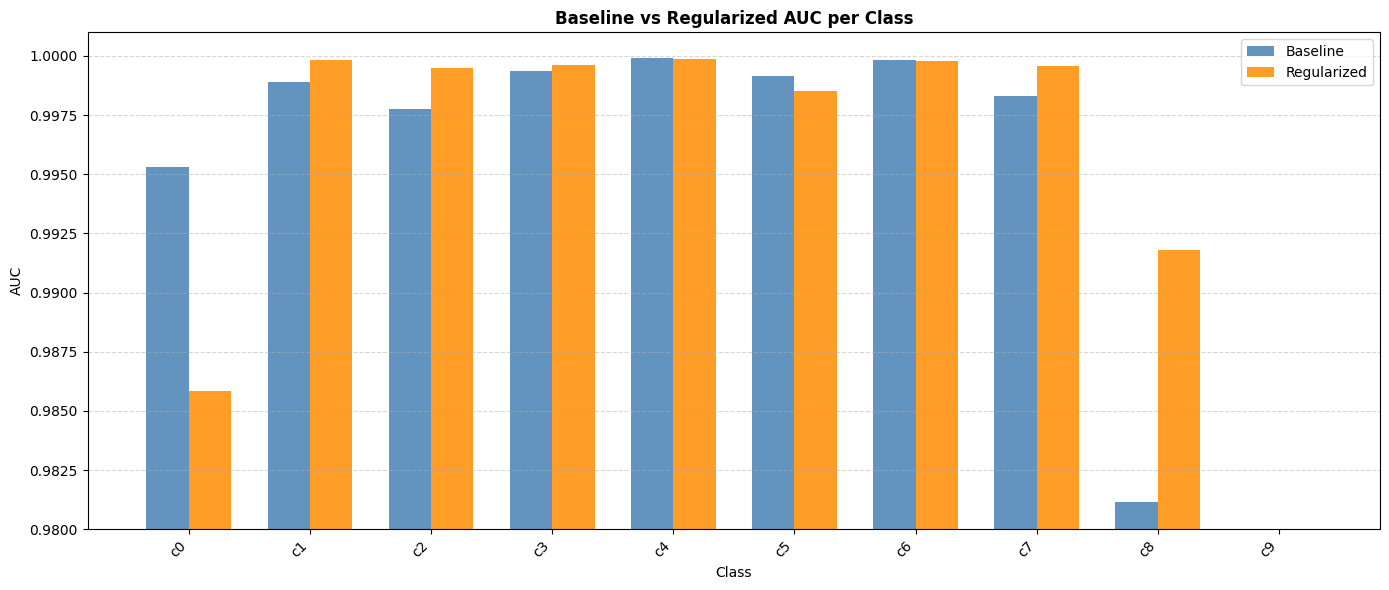

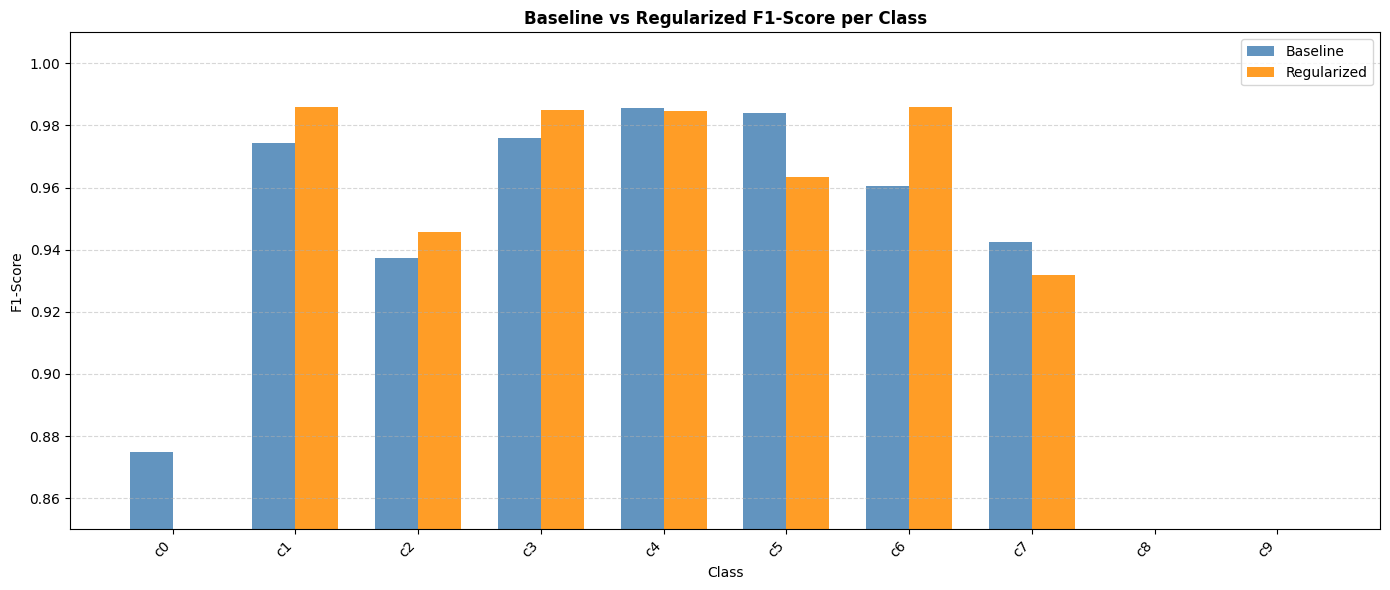

In [12]:
#AUC comparison bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(NUM_CLASSES)
width = 0.35

ax.bar(x - width/2, auc_baseline,    width, label="Baseline",    color="steelblue",  alpha=0.85)
ax.bar(x + width/2, auc_regularized, width, label="Regularized", color="darkorange", alpha=0.85)

ax.set_xlabel("Class")
ax.set_ylabel("AUC")
ax.set_title("Baseline vs Regularized AUC per Class", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(SHORT_NAMES, rotation=45, ha="right")
ax.set_ylim(0.98, 1.001)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "comparison_auc.png", dpi=150, bbox_inches="tight")
plt.show()


#F1 comparison
f1_b = f1_score(y_true_b, y_pred_b, average=None)
f1_r = f1_score(y_true_r, y_pred_r, average=None)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, f1_b, width, label="Baseline",    color="steelblue",  alpha=0.85)
ax.bar(x + width/2, f1_r, width, label="Regularized", color="darkorange", alpha=0.85)
ax.set_xlabel("Class")
ax.set_ylabel("F1-Score")
ax.set_title("Baseline vs Regularized F1-Score per Class", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(SHORT_NAMES, rotation=45, ha="right")
ax.set_ylim(0.85, 1.01)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "comparison_f1.png", dpi=150, bbox_inches="tight")
plt.show()

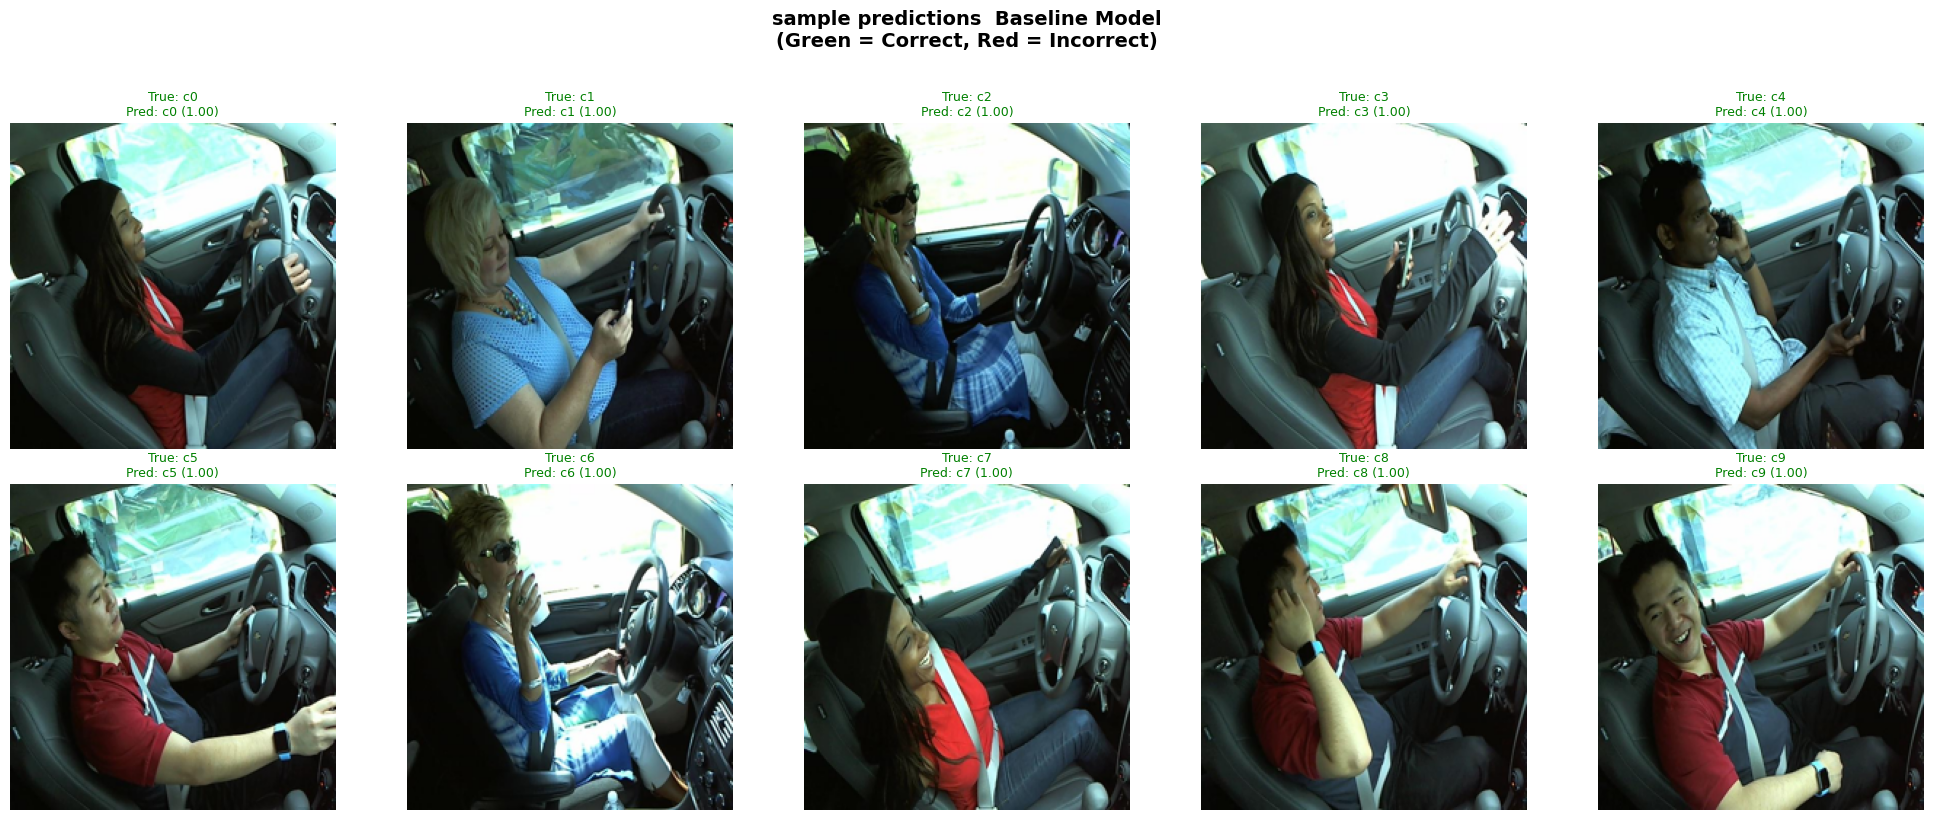

In [13]:
def show_sample_predictions(model, val_dir, n_per_class=1, save_path=None):
    #sample predictions
    val_path = Path(val_dir)
    class_folders = sorted([d for d in val_path.iterdir() if d.is_dir()])

    samples = []
    for folder in class_folders:
        imgs = list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.png"))
        if imgs:
            samples.append((folder.name, imgs[0]))

    n_cols = 5
    n_rows = (len(samples) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()

    for idx, (true_class, img_path) in enumerate(samples):
        result  = model.predict(str(img_path), imgsz=224, verbose=False)[0]
        pred_idx = result.probs.top1
        pred_class = result.names[pred_idx]
        conf = float(result.probs.top1conf)

        img = Image.open(img_path).resize((224, 224))
        axes[idx].imshow(img)
        axes[idx].axis("off")

        correct = (true_class == pred_class)
        color   = "green" if correct else "red"
        title   = f"True: {true_class}\nPred: {pred_class} ({conf:.2f})"
        axes[idx].set_title(title, fontsize=9, color=color)

        for spine in axes[idx].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

    # hide empty subplots
    for idx in range(len(samples), len(axes)):
        axes[idx].axis("off")

    plt.suptitle("sample predictions  Baseline Model\n(Green = Correct, Red = Incorrect)",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


show_sample_predictions(model_baseline, VAL_DIR,
    save_path=REPORTS_DIR / "sample_predictions.png")